In [ ]:
# ★★このセルを実行後セッションを再起動してください★★
# kerasとtensorflowのバージョン整理
!pip uninstall -y keras
!pip install -U keras==2.15.0 tensorflow==2.15.0 --quiet

In [1]:
# GPUの割り当てを確認
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sun Apr 20 11:13:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ドライブのマウント
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
%cd drive/MyDrive/ssd_tf2_lowlevel_study/ssd_keras/
!pwd

/content/drive/MyDrive/ssd_tf2_lowlevel_study/ssd_keras
/content/drive/MyDrive/ssd_tf2_lowlevel_study/ssd_keras


In [33]:
!pip uninstall -y keras  # ← スタンドアロンKerasを削除
import cv2
from tensorflow import keras
from tensorflow.keras.applications.imagenet_utils import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import pickle
from random import shuffle
from imageio import imread
from PIL import Image
import tensorflow as tf
import os

from ssd_tf2 import SSD300
from ssd_training_tf2 import MultiboxLoss
from ssd_utils_tf2 import BBoxUtility

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['image.interpolation'] = 'nearest'

np.set_printoptions(suppress=True)

threshold = 0.4 #モデル判定のしきい値

new_weights_name = '1_epoch-1_step-200_loss-3.5138'
path_prefix = '/content/drive/MyDrive/ssd_workspace/VOCdevkit/train/VOC2007/JPEGImages/'
model_save_path = '/content/drive/MyDrive/ssd_tf2_lowlevel_study/ssd_keras/checkpoints/'


# config = tf.ConfigProto()
# config.gpu_options.per_process_gpu_memory_fraction = 0.9
# set_session(tf.Session(config=config))

In [34]:
# some constants
NUM_CLASSES = 21
input_shape = (300, 300, 3)

In [35]:
import time
import threading

def keep_alive():
    while True:
        print("Keeping session alive...")
        time.sleep(600)  # 10分間隔で出力

# バックグラウンドスレッドを起動
thread = threading.Thread(target=keep_alive, daemon=True)  # daemon=True でバックグラウンド実行
thread.start()

print("バックグラウンドでセッションを維持中...")

Keeping session alive...
バックグラウンドでセッションを維持中...


In [36]:
priors = pickle.load(open('prior_boxes_ssd300.pkl', 'rb'))
bbox_util = BBoxUtility(NUM_CLASSES, priors)

In [37]:
gt = pickle.load(open('VOC2007.pkl', 'rb'))
keys = sorted(gt.keys())
num_train = int(round(0.8 * len(keys)))
train_keys = keys[:num_train]
val_keys = keys[num_train:]
num_val = len(val_keys)

In [54]:
def count_ext_files(directory, ext, not_ext=None):
    # ディレクトリ内のすべてのファイルをリスト化
    files = os.listdir(directory)
    # HTMLファイルのみを抽出してカウント
    ext_files = [file for file in files if file.endswith(ext)]
    ext_files = [file for file in ext_files if not_ext is None or not file.endswith(not_ext)]
    # print(f"{ext}ファイル: {ext_files}")
    return len(ext_files)

class Generator(object):
    def __init__(self, gt, bbox_util,
                 batch_size, path_prefix,
                 train_keys, val_keys, image_size,
                 saturation_var=0.5,
                 brightness_var=0.5,
                 contrast_var=0.5,
                 lighting_std=0.5,
                 hflip_prob=0.5,
                 vflip_prob=0.5,
                 do_crop=True,
                 crop_area_range=[0.75, 1.0],
                 aspect_ratio_range=[3./4., 4./3.]):
        self.gt = gt
        self.bbox_util = bbox_util
        self.batch_size = batch_size
        self.path_prefix = path_prefix
        self.train_keys = train_keys
        self.val_keys = val_keys
        self.train_batches = len(train_keys)
        self.val_batches = len(val_keys)
        self.image_size = image_size
        self.color_jitter = []
        if saturation_var:
            self.saturation_var = saturation_var
            self.color_jitter.append(self.saturation)
        if brightness_var:
            self.brightness_var = brightness_var
            self.color_jitter.append(self.brightness)
        if contrast_var:
            self.contrast_var = contrast_var
            self.color_jitter.append(self.contrast)
        self.lighting_std = lighting_std
        self.hflip_prob = hflip_prob
        self.vflip_prob = vflip_prob
        self.do_crop = do_crop
        self.crop_area_range = crop_area_range
        self.aspect_ratio_range = aspect_ratio_range

    def grayscale(self, rgb):
        return rgb.dot([0.299, 0.587, 0.114])

    def saturation(self, rgb):
        gs = self.grayscale(rgb)
        alpha = 2 * np.random.random() * self.saturation_var
        alpha += 1 - self.saturation_var
        rgb = rgb * alpha + (1 - alpha) * gs[:, :, None]
        return np.clip(rgb, 0, 255)

    def brightness(self, rgb):
        alpha = 2 * np.random.random() * self.brightness_var
        alpha += 1 - self.saturation_var
        rgb = rgb * alpha
        return np.clip(rgb, 0, 255)

    def contrast(self, rgb):
        gs = self.grayscale(rgb).mean() * np.ones_like(rgb)
        alpha = 2 * np.random.random() * self.contrast_var
        alpha += 1 - self.contrast_var
        rgb = rgb * alpha + (1 - alpha) * gs
        return np.clip(rgb, 0, 255)

    def lighting(self, img):
        cov = np.cov(img.reshape(-1, 3) / 255.0, rowvar=False)
        eigval, eigvec = np.linalg.eigh(cov)
        noise = np.random.randn(3) * self.lighting_std
        noise = eigvec.dot(eigval * noise) * 255
        img += noise
        return np.clip(img, 0, 255)

    def horizontal_flip(self, img, y):
        if np.random.random() < self.hflip_prob:
            img = img[:, ::-1]
            y[:, [0, 2]] = 1 - y[:, [2, 0]]
        return img, y

    def vertical_flip(self, img, y):
        if np.random.random() < self.vflip_prob:
            img = img[::-1]
            y[:, [1, 3]] = 1 - y[:, [3, 1]]
        return img, y

    def random_sized_crop(self, img, targets):
        img_w = img.shape[1]
        img_h = img.shape[0]
        img_area = img_w * img_h
        random_scale = np.random.random()
        random_scale *= (self.crop_area_range[1] -
                         self.crop_area_range[0])
        random_scale += self.crop_area_range[0]
        target_area = random_scale * img_area
        random_ratio = np.random.random()
        random_ratio *= (self.aspect_ratio_range[1] -
                         self.aspect_ratio_range[0])
        random_ratio += self.aspect_ratio_range[0]
        w = np.round(np.sqrt(target_area * random_ratio))
        h = np.round(np.sqrt(target_area / random_ratio))
        if np.random.random() < 0.5:
            w, h = h, w
        w = min(w, img_w)
        w_rel = w / img_w
        w = int(w)
        h = min(h, img_h)
        h_rel = h / img_h
        h = int(h)
        x = np.random.random() * (img_w - w)
        x_rel = x / img_w
        x = int(x)
        y = np.random.random() * (img_h - h)
        y_rel = y / img_h
        y = int(y)
        img = img[y:y+h, x:x+w]
        new_targets = []
        for box in targets:
            cx = 0.5 * (box[0] + box[2])
            cy = 0.5 * (box[1] + box[3])
            if (x_rel < cx < x_rel + w_rel and
                y_rel < cy < y_rel + h_rel):
                xmin = (box[0] - x_rel) / w_rel
                ymin = (box[1] - y_rel) / h_rel
                xmax = (box[2] - x_rel) / w_rel
                ymax = (box[3] - y_rel) / h_rel
                xmin = max(0, xmin)
                ymin = max(0, ymin)
                xmax = min(1, xmax)
                ymax = min(1, ymax)
                box[:4] = [xmin, ymin, xmax, ymax]
                new_targets.append(box)
        new_targets = np.asarray(new_targets).reshape(-1, targets.shape[1])
        return img, new_targets

    def generate(self, train=True):
        while True:
            if train:
                shuffle(self.train_keys)
                keys = self.train_keys
            else:
                shuffle(self.val_keys)
                keys = self.val_keys
            inputs = []
            targets = []
            for key in keys:
                img_path = self.path_prefix + key
                img = imread(img_path).astype('float32')
                y = self.gt[key].copy()
                if train and self.do_crop:
                    img, y = self.random_sized_crop(img, y)
                img = np.array(Image.fromarray((img * 255).astype(np.uint8)).resize(self.image_size)).astype('float32')
                if train:
                    shuffle(self.color_jitter)
                    for jitter in self.color_jitter:
                        img = jitter(img)
                    if self.lighting_std:
                        img = self.lighting(img)
                    if self.hflip_prob > 0:
                        img, y = self.horizontal_flip(img, y)
                    if self.vflip_prob > 0:
                        img, y = self.vertical_flip(img, y)
                y = self.bbox_util.assign_boxes(y)
                inputs.append(img)
                targets.append(y)
                if len(targets) == self.batch_size:
                    tmp_inp = np.array(inputs)
                    tmp_targets = np.array(targets)
                    inputs = []
                    targets = []
                    yield preprocess_input(tmp_inp), tmp_targets

class LossLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"Epoch {epoch}: loss={logs.get('loss'):.4f}, val_loss={logs.get('val_loss'):.4f}")
        with open(f'{model_save_path}log/loss_log.txt', 'a') as f:
            f.write(f"{epoch+1},{logs.get('loss'):.4f},{logs.get('val_loss'):.4f}\n")


class FrequentSaver(tf.keras.callbacks.Callback):
    def __init__(self, save_every=100):
        super().__init__()
        self.save_every = save_every  # 何バッチごとに保存するか
        self.batch_counter = 0


    def on_epoch_begin(self, epoch, logs=None):
        self.current_epoch = epoch  # エポック番号を保持！

    def on_train_batch_end(self, batch, logs=None):
        self.batch_counter += 1
        if self.batch_counter % self.save_every == 0:
            weights_num = count_ext_files(model_save_path + '100_steps/', ext='.weights.h5')
            filename = f"{model_save_path}100_steps/{weights_num}_epoch-{self.current_epoch:02d}_step-{self.batch_counter:05d}_loss-{logs.get('loss'):.4f}.weights.h5"
            self.model.save_weights(filename)
            print(f'重み保存完了！ → {filename}')



In [55]:
gen = Generator(gt, bbox_util, 16, path_prefix,
                train_keys, val_keys,
                (input_shape[0], input_shape[1]), do_crop=False)

In [56]:
model = SSD300(input_shape, num_classes=NUM_CLASSES)
model.load_weights('weights_SSD300.hdf5', by_name=True)

In [57]:
freeze = ['input_1', 'conv1_1', 'conv1_2', 'pool1',
          'conv2_1', 'conv2_2', 'pool2',
          'conv3_1', 'conv3_2', 'conv3_3', 'pool3']#,
#           'conv4_1', 'conv4_2', 'conv4_3', 'pool4']

for L in model.layers:
    if L.name in freeze:
        L.trainable = False

In [58]:
def schedule(epoch, decay=0.9):
    return base_lr * decay**(epoch)


callbacks = [keras.callbacks.ModelCheckpoint(model_save_path + 'weights_epoch-{epoch:02d}_loss-{val_loss:.2f}.weights.h5',
                                             monitor='val_loss',
                                             verbose=1,
                                             save_weights_only=True),
             keras.callbacks.LearningRateScheduler(schedule),
             LossLogger(),
             FrequentSaver(save_every=100)]

In [59]:
base_lr = 3e-4
optim = keras.optimizers.Adam(learning_rate=base_lr)
# optim = keras.optimizers.RMSprop(learning_rate=base_lr)
# optim = keras.optimizers.SGD(learning_rate=base_lr, momentum=0.9, decay=decay, nesterov=True)
model.compile(optimizer=optim,
              loss=MultiboxLoss(NUM_CLASSES, neg_pos_ratio=2.0).compute_loss,
              jit_compile=False)
model.load_weights(f'{model_save_path}{new_weights_name}.weights.h5')

In [60]:
nb_epoch = 30
history = model.fit(gen.generate(True),
                    steps_per_epoch=gen.train_batches,
                    epochs=nb_epoch,
                    verbose=1,
                    callbacks=callbacks,
                    validation_data=gen.generate(False),
                    validation_steps=gen.val_batches)

<ipython-input-54-b45beb284f11>:153: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imread(img_path).astype('float32')


Epoch 1/30
  78/4009 ━━━━━━━━━━━━━━━━━━━━ 31:29 481ms/step - loss: 3.4064Keeping session alive...
  99/4009 ━━━━━━━━━━━━━━━━━━━━ 31:24 482ms/step - loss: 3.3874重み保存完了！ → /content/drive/MyDrive/ssd_tf2_lowlevel_study/ssd_keras/checkpoints/100_steps/0_epoch-00_step-00100_loss-3.3150.weights.h5
 199/4009 ━━━━━━━━━━━━━━━━━━━━ 30:54 487ms/step - loss: 3.3521重み保存完了！ → /content/drive/MyDrive/ssd_tf2_lowlevel_study/ssd_keras/checkpoints/100_steps/1_epoch-00_step-00200_loss-3.3157.weights.h5
 209/4009 ━━━━━━━━━━━━━━━━━━━━ 30:52 488ms/step - loss: 3.3502Keeping session alive...
 299/4009 ━━━━━━━━━━━━━━━━━━━━ 30:20 491ms/step - loss: 3.3313重み保存完了！ → /content/drive/MyDrive/ssd_tf2_lowlevel_study/ssd_keras/checkpoints/100_steps/2_epoch-00_step-00300_loss-3.2659.weights.h5
 399/4009 ━━━━━━━━━━━━━━━━━━━━ 29:32 491ms/step - loss: 3.3092重み保存完了！ → /content/drive/MyDrive/ssd_tf2_lowlevel_study/ssd_keras/checkpoints/100_steps/3_epoch-00_step-00400_loss-3.2214.weights.h5
 499/4009 ━━━━━━━━━━━━━━━━━━━━ 28:5

In [67]:
# 手動で保存
save_model_name = 'epoch-30_step-0000_loss-1.9178_valloss-2.9057' # ←これだけは毎回手動で編集！

# ファイルカウント
weights_num = count_ext_files(model_save_path, ext='.weights.h5')
model_num = count_ext_files(model_save_path, ext='.keras')

# 保存
model.save_weights(f'{model_save_path}{weights_num}_{save_model_name}.weights.h5')
model.save(f'{model_save_path}{model_num}_{save_model_name}.keras', include_optimizer=True)


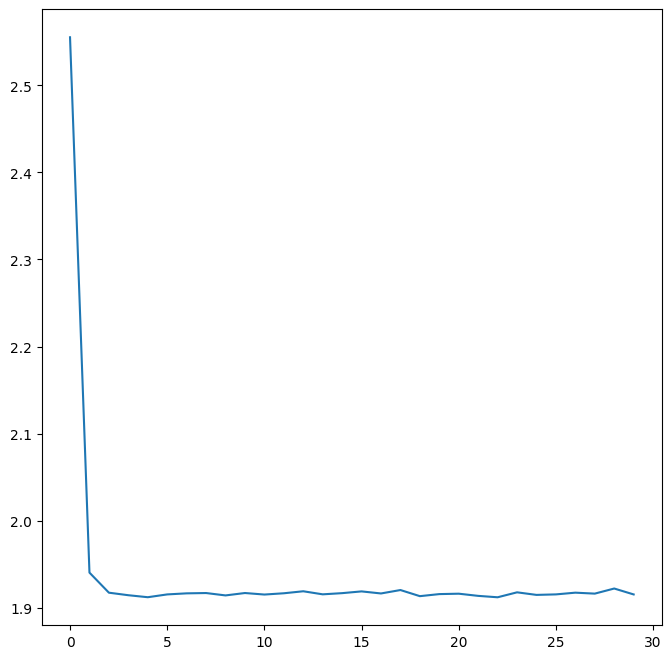

In [73]:
plt.plot(history.history['loss'], label='loss')

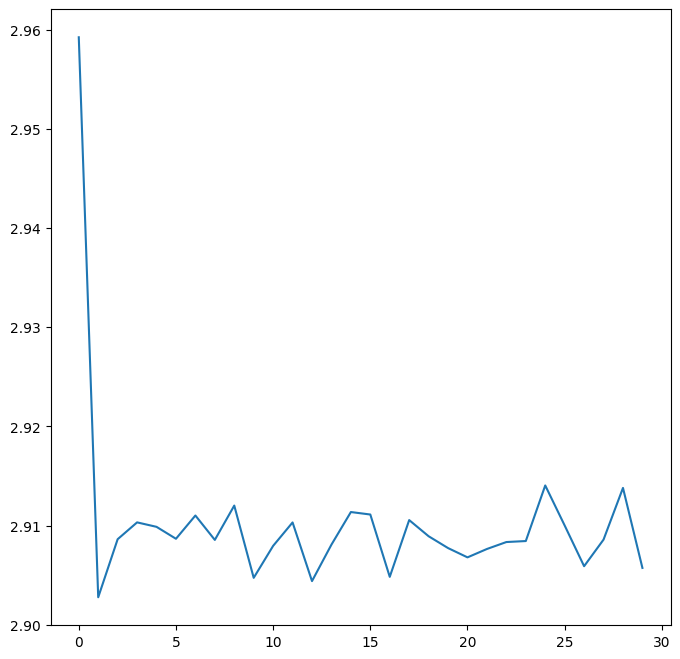

In [74]:
plt.plot(history.history['val_loss'], label='val_loss')

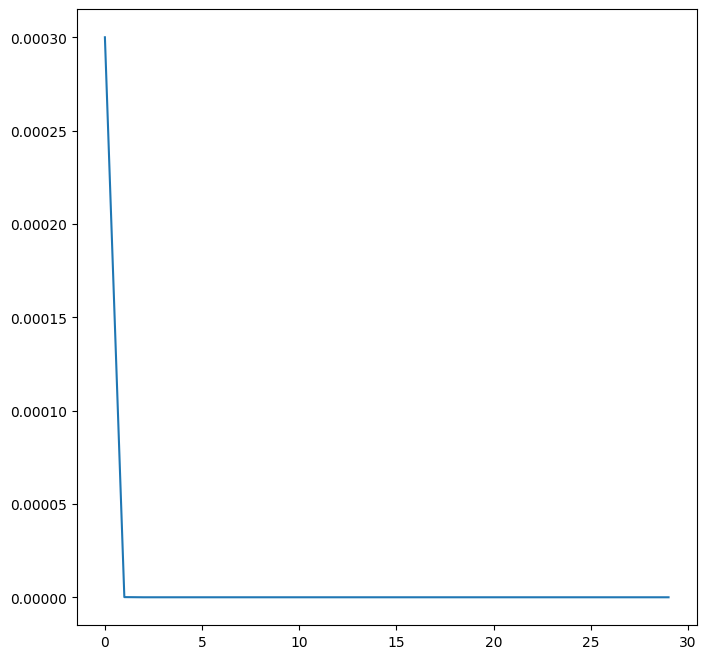

In [75]:
plt.plot(history.history['learning_rate'], label='learning_rate')

In [69]:
# 自動で取り出せるか試す
print(history.history.keys())
# last_loss = history.history['loss'][-1]
# save_model_name = f'epoch-{nb_epoch:02d}_step-{gen.train_batches}_loss-{last_loss:.4f}'
# model.save_weights(f'{model_save_path}{save_model_name}.weights.h5')

dict_keys(['loss', 'val_loss', 'learning_rate'])


In [63]:
!ls -l /content/drive/MyDrive/ssd_tf2_lowlevel_study/ssd_keras/checkpoints/

total 9811838
-rw------- 1 root root 295506960 Apr 20 11:35 0_epoch-1_loss-4.4617.weights.h5
-rw------- 1 root root 295567048 Apr 21 05:24 0_epoch-1_step-8_loss-3.3652.keras
drwx------ 2 root root      4096 Apr 21 05:19 100_steps
-rw------- 1 root root 295506960 Apr 20 11:35 1_epoch-1_step-200_loss-3.5138.weights.h5
-rw------- 1 root root 295506960 Apr 21 05:24 32_epoch-1_step-8_loss-3.3652.weights.h5
drwx------ 2 root root      4096 Apr 21 05:24 log
-rw------- 1 root root 295506960 Apr 20 12:37 weights_epoch-01_loss-2.96.weights.h5
-rw------- 1 root root 295506960 Apr 20 13:13 weights_epoch-02_loss-2.90.weights.h5
-rw------- 1 root root 295506960 Apr 20 13:48 weights_epoch-03_loss-2.91.weights.h5
-rw------- 1 root root 295506960 Apr 20 14:24 weights_epoch-04_loss-2.91.weights.h5
-rw------- 1 root root 295506960 Apr 20 15:00 weights_epoch-05_loss-2.91.weights.h5
-rw------- 1 root root 295506960 Apr 20 15:36 weights_epoch-06_loss-2.91.weights.h5
-rw------- 1 root root 295506960 Apr 20 1

In [76]:
inputs = []
images = []
img_path = path_prefix + sorted(val_keys)[0]
img = image.load_img(img_path, target_size=(300, 300))
img = image.img_to_array(img)
images.append(imread(img_path))
inputs.append(img.copy())
inputs = preprocess_input(np.array(inputs))

<ipython-input-76-62804db66c55>:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imread(img_path))


In [65]:
results = bbox_util.detection_out(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


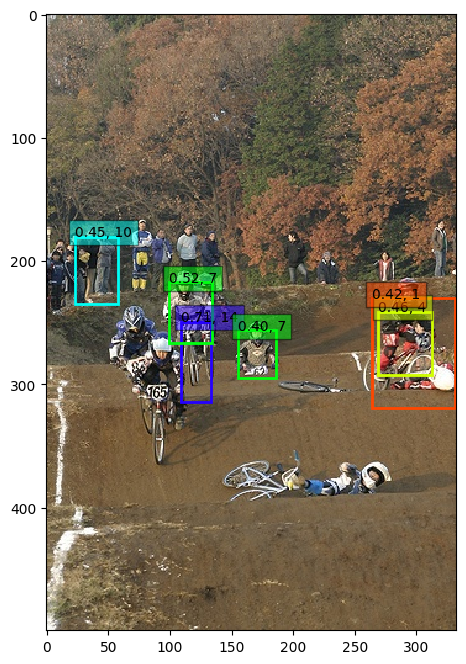

In [84]:
for i, img in enumerate(images):
    # Parse the outputs.
    det_label = results[i][:, 0]
    det_conf = results[i][:, 1]
    det_xmin = results[i][:, 2]
    det_ymin = results[i][:, 3]
    det_xmax = results[i][:, 4]
    det_ymax = results[i][:, 5]

    # Get detections with confidence higher than 0.6.
    top_indices = [i for i, conf in enumerate(det_conf) if conf >= threshold]

    top_conf = det_conf[top_indices]
    top_label_indices = det_label[top_indices].tolist()
    top_xmin = det_xmin[top_indices]
    top_ymin = det_ymin[top_indices]
    top_xmax = det_xmax[top_indices]
    top_ymax = det_ymax[top_indices]

    colors = plt.cm.hsv(np.linspace(0, 1, NUM_CLASSES)).tolist()

    plt.imshow(img / 255.)
    currentAxis = plt.gca()

    for i in range(top_conf.shape[0]):
        xmin = int(round(top_xmin[i] * img.shape[1]))
        ymin = int(round(top_ymin[i] * img.shape[0]))
        xmax = int(round(top_xmax[i] * img.shape[1]))
        ymax = int(round(top_ymax[i] * img.shape[0]))
        score = top_conf[i]
        label = int(top_label_indices[i])
        # label_name = voc_classes[label - 1]
        display_txt = '{:0.2f}, {}'.format(score, label)
        coords = (xmin, ymin), xmax-xmin+1, ymax-ymin+1
        color = colors[label]
        currentAxis.add_patch(plt.Rectangle(*coords, fill=False, edgecolor=color, linewidth=2))
        currentAxis.text(xmin, ymin, display_txt, bbox={'facecolor':color, 'alpha':0.5})

    plt.show()